Index(['Incident ID', 'Date', 'Time', 'Category', 'Severity', 'Department',
       'Location', 'Description', 'Root Cause', 'Injuries', 'Lost Time Days',
       'Corrective Action', 'Status', 'Closed Date',
       'Severity (Numeric) 1=Near Miss … 5=Critical',
       'Category (Numeric) See legend', 'Department (Numeric) See legend',
       'Location (Numeric) See legend', 'Root Cause (Numeric) See legend',
       'Status (Numeric) See legend', 'Month (1–12)',
       'Day of Week 1=Mon … 7=Sun'],
      dtype='object')


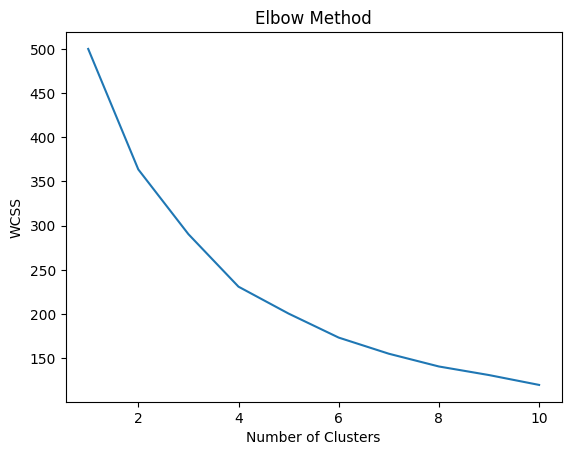

  Incident ID   Severity  Lost Time Days  Cluster
0    INC-0061  Near Miss               0        2
1    INC-0096        Low               0        2
2    INC-0037     Medium               5        2
3    INC-0045   Critical               4        1
4    INC-0008        Low               0        1
5    INC-0027     Medium               4        2
6    INC-0098        Low               0        1
7    INC-0063        Low               0        2
8    INC-0081        Low               0        1
9    INC-0019  Near Miss               0        2


In [9]:
# ----------------------------------
# K-MEANS CLUSTERING
# INDUSTRIAL INCIDENT DATASET
# ----------------------------------

import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


# --------------------
# LOAD DATASET
# --------------------

df = pd.read_excel("industrial_incident_reports (1).xlsx")

# Clean column names
df.columns = df.columns.str.replace('\n',' ')
df.columns = df.columns.str.strip()

print(df.columns)


# --------------------
# FEATURES (NO TARGET)
# --------------------

X = df[[
    'Severity (Numeric) 1=Near Miss … 5=Critical',
    'Category (Numeric) See legend',
    'Department (Numeric) See legend',
    'Injuries',
    'Lost Time Days'
]]


# --------------------
# FEATURE SCALING
# --------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# --------------------
# ELBOW METHOD
# --------------------

wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# Plot elbow graph

plt.plot(range(1,11),wcss)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()


# --------------------
# APPLY KMEANS
# --------------------

kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(X_scaled)

df["Cluster"]=clusters


# --------------------
# SHOW RESULTS
# --------------------

print(df[[
    'Incident ID',
    'Severity',
    'Lost Time Days',
    'Cluster'
]].head(10))